In [1]:
!pip install import-ipynb
!pip install scikit-learn joblib

### Preprocessing Pipeline

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 33.2073


Class 0 Epoch 2, Total Loss: 20.2330


Class 0 Epoch 3, Total Loss: 18.0151


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0768


Class 2 Epoch 2, Total Loss: 4.1095


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0616211].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0735948].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0137256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0576298].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0097344].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.005743].


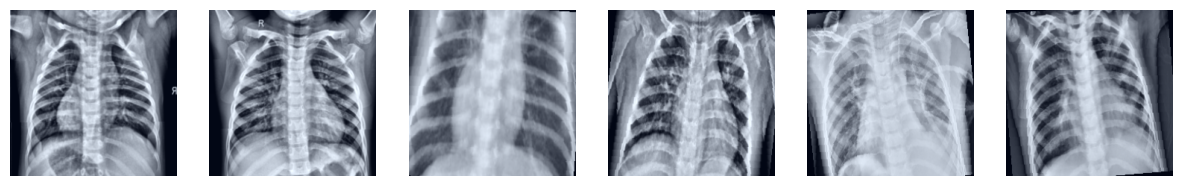

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [2]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt

### Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


### DATALOADERS

In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(
    prep.train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    prep.val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    prep.test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

NUM_CLASSES = len(prep.train_dataset.classes)

## CNN FEATURE EXTRACTOR
1. EfficientNet-B4 pretrained on ImageNet
2. Remove classification layer
3. Output feature vector size = 1792

In [6]:
base_model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)

feature_extractor = nn.Sequential(
    base_model.features,
    base_model.avgpool,
    nn.Flatten()
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

print("\n✅ EfficientNet-B4 Feature Extractor Loaded")


✅ EfficientNet-B4 Feature Extractor Loaded


In [7]:
def extract_features(loader):
    features_list = []
    labels_list = []
    print("\nExtracting CNN Features...")
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            features = feature_extractor(images)
            features = features.cpu().numpy()
            features_list.append(features)
            labels_list.extend(labels.numpy())
    X = np.concatenate(features_list,axis=0)
    y = np.array(labels_list)
    return X, y

In [12]:
X_train, y_train = extract_features(train_loader)
X_val, y_val = extract_features(val_loader)
X_test, y_test = extract_features(test_loader)
print("\nFeature Shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Extracting CNN Features...


100%|██████████| 120/120 [03:24<00:00,  1.70s/it]



Extracting CNN Features...


100%|██████████| 6/6 [00:09<00:00,  1.51s/it]



Extracting CNN Features...


100%|██████████| 19/19 [00:27<00:00,  1.46s/it]


Feature Shapes:
Train: (3819, 1792)
Validation: (186, 1792)
Test: (604, 1792)


In [13]:
X_train_full = np.concatenate([X_train, X_val], axis=0)
y_train_full = np.concatenate([y_train, y_val], axis=0)

### PCA DIMENSIONALITY REDUCTION
1. Reduce high-dimensional CNN vectors
2. Keeps most important information

In [14]:
print("APPLYING PCA")
pca = PCA(n_components=0.95,random_state=42)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca = pca.transform(X_test)

print("\nOriginal Shape:", X_train_full.shape)
print("Reduced Shape:", X_train_pca.shape)
print(
    f"Explained Variance: "
    f"{sum(pca.explained_variance_ratio_):.4f}"
)

APPLYING PCA

Original Shape: (4005, 1792)
Reduced Shape: (4005, 417)
Explained Variance: 0.9501


### Rondom Forest Classifier

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

### Model Training

In [16]:
print("TRAINING RANDOM FOREST")
rf_model.fit(X_train_pca,y_train_full)
print("\n✅ Random Forest Training Complete")

TRAINING RANDOM FOREST


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:    1.5s



✅ Random Forest Training Complete


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    1.8s finished


### Predictions

In [17]:
y_pred = rf_model.predict(X_test_pca)
y_probs = rf_model.predict_proba(X_test_pca)

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.0s finished


### Evaluation Metrics

In [18]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("TEST RESULTS")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

TEST RESULTS
Accuracy: 0.6275
F1 Score: 0.6183


### Classification Report

In [19]:
print("CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=prep.train_dataset.classes
    )
)

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.73      0.84      0.78       234
             NORMAL       0.68      0.41      0.51       227
    VIRAL_PNEUMONIA       0.45      0.63      0.53       143

           accuracy                           0.63       604
          macro avg       0.62      0.63      0.61       604
       weighted avg       0.64      0.63      0.62       604



### Confusion Matrix

<Figure size 800x800 with 0 Axes>

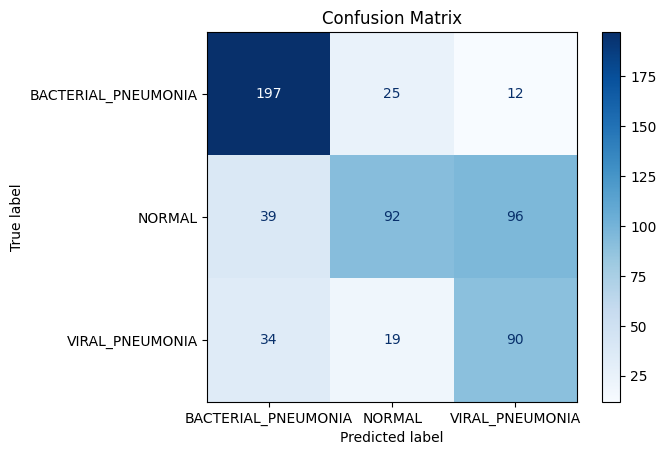

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=prep.train_dataset.classes)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### ROC-AUC CURVES

In [24]:
y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
fpr = {}
tpr = {}
roc_auc = {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_probs[:, i]
    )
    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

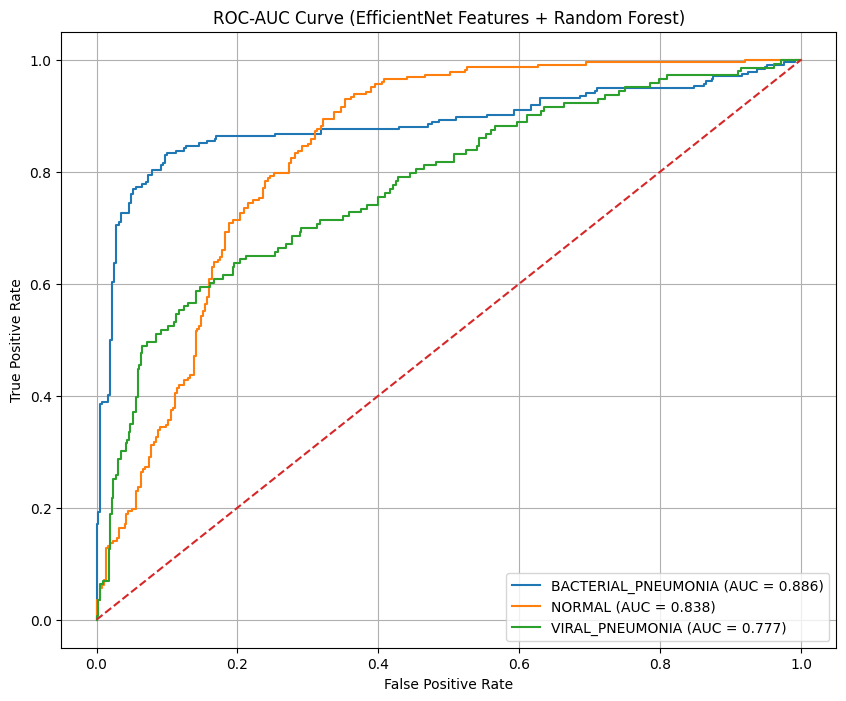

In [25]:
plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{prep.train_dataset.classes[i]} "
              f"(AUC = {roc_auc[i]:.3f})"
    )
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC-AUC Curve "
    "(EfficientNet Features + Random Forest)"
)
plt.legend()
plt.grid()
plt.show()

In [26]:
overall_auc = roc_auc_score(y_test_bin, y_probs,multi_class='ovr')
print(
    f"\nOverall ROC-AUC Score: "
    f"{overall_auc:.4f}"
)


Overall ROC-AUC Score: 0.8335


### PCA Variance Graph

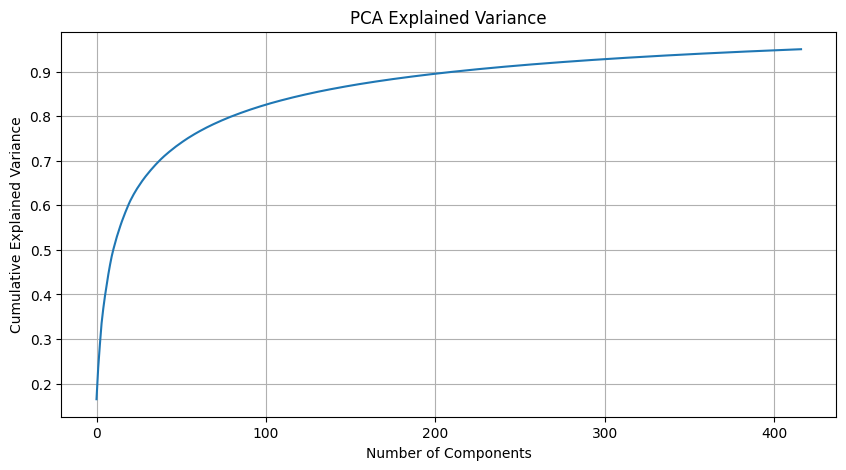

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

### Feature Importance

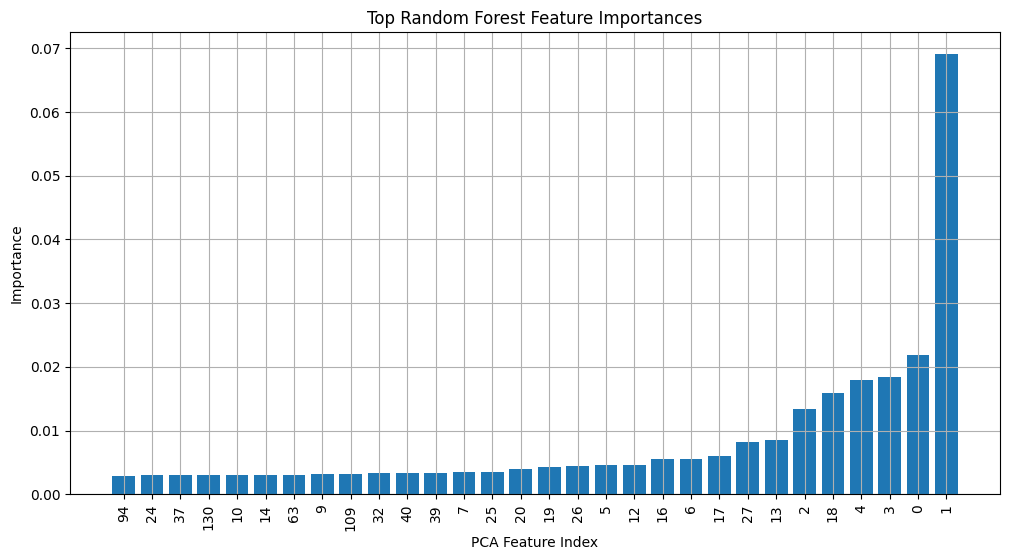

In [28]:
feature_importance = rf_model.feature_importances_
top_k = 30
top_indices = np.argsort(
    feature_importance
)[-top_k:]
plt.figure(figsize=(12, 6))
plt.bar(
    range(top_k),
    feature_importance[top_indices]
)
plt.xticks(
    range(top_k),
    top_indices,
    rotation=90
)
plt.xlabel("PCA Feature Index")
plt.ylabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.grid()
plt.show()

### Save Model

In [29]:
joblib.dump(
    rf_model,
    "RF_EfficientNet_Pneumonia.pkl"
)
joblib.dump(
    pca,
    "PCA_EfficientNet.pkl"
)
torch.save(
    feature_extractor.state_dict(),
    "EfficientNet_FeatureExtractor.pth"
)
print("\n✅ Models Saved Successfully")


✅ Models Saved Successfully


In [30]:
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)
print("✅ Class Names Saved")

✅ Class Names Saved
